# Set up

In [34]:
import pandas as pd
import os
import matplotlib as plt

from surprise import Reader, AlgoBase, Dataset, accuracy
from surprise.model_selection import train_test_split
import numpy as np
from collections import defaultdict
import recmetrics
from sklearn.metrics import ndcg_score

from sklearn.preprocessing import StandardScaler

from surprise.model_selection import cross_validate, KFold

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.preprocessing import normalize

In [35]:
SEED = 42; TOP_K = 10; RELEVANCE_THRESHOLD = 7; MIN_ITEM_RATINGS = 500
N_USERS = 5000; N_USERS_COVERAGE = 300

np.random.seed(SEED)
ratings_df = pd.read_csv("../processed_data/explicit_ratings.csv")

# We shuffle the users
all_users = ratings_df["user_id"].unique()
np.random.shuffle(all_users)

# Readers for our ranking (implemented wide as some ratings go above 10. Showed improvement!)
reader      = Reader(rating_scale=(1, 10))
reader_wide = Reader(rating_scale=(1, 20))

# We sample the 5000 users
sample = ratings_df[ratings_df["user_id"].isin(all_users[:N_USERS])][["user_id", "anime_id", "rating"]]
data = Dataset.load_from_df(sample, reader)
trainset, testset = train_test_split(data, test_size=0.2, random_state=SEED) # Normal 80/20 split

# For coverage, we are using only 300 people as the matrix with 6000 catalog items would be 1.8M predictions and not 30M with 5k users.
sample_cov = ratings_df[ratings_df["user_id"].isin(all_users[:N_USERS_COVERAGE])][["user_id", "anime_id", "rating"]]
data_cov = Dataset.load_from_df(sample_cov, reader_wide)
trainset_cov = data_cov.build_full_trainset() 
# We are using the whole dataset for training as we want to have as much information for computing coverage
antitestset_cov = trainset_cov.build_anti_testset() # all user item pairs which are not in the trainset
catalog = [trainset_cov.to_raw_iid(iid) for iid in trainset_cov.all_items()]

genre_cols = ['Action', 'Adventure', 'Cars', 'Comedy', 'Dementia', 'Demons', 'Drama', 'Ecchi', 'Fantasy', 'Game', 'Harem', 'Historical', 'Horror', 'Josei', 'Kids', 'Magic', 'Martial Arts', 'Mecha', 'Military', 'Music', 'Mystery', 'Parody', 'Police', 'Psychological', 'Romance', 'Samurai', 'School', 'Sci-Fi', 'Seinen', 'Shoujo', 'Shoujo Ai', 'Shounen', 'Shounen Ai', 'Slice of Life', 'Space', 'Sports', 'Super Power', 'Supernatural', 'Thriller', 'Vampire', 'Yaoi']
anime_meta = pd.read_csv("../processed_data/anime_processed.csv")[["MAL_ID"] + genre_cols].set_index("MAL_ID")

In [36]:
import gc

def get_top_n(predictions, n=TOP_K):
    """
        Function takes prediction and sorts them to return the top K recommendations.
        - Sorts predictions based on estimated rating (in a descending manner)
        - Limits to only top K numbers
    """
    user_preds = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        user_preds[uid].append((iid, est, true_r))
    return {uid: sorted(v, key=lambda x: x[1], reverse=True)[:n] for uid, v in user_preds.items()}

def eval_accuracy(predictions, n=TOP_K, threshold=RELEVANCE_THRESHOLD):
    """
        Function which computes all relevant regression, classification and ranking metrics.
        Responsible for MAE, RMSE, Precision, Recall, and NDCG
    """
    rmse = accuracy.rmse(predictions, verbose=False)
    mae  = accuracy.mae(predictions, verbose=False)
    user_preds = defaultdict(list)
    for uid, iid, true_r, est, _ in predictions:
        user_preds[uid].append((iid, est, true_r))
    precisions, recalls, ndcgs = [], [], []
    for uid, preds in user_preds.items():
        top = sorted(preds, key=lambda x: x[1], reverse=True)[:n]
        hits      = sum(r >= threshold for _, _, r in top)
        total_rel = sum(r >= threshold for _, _, r in preds)
        precisions.append(hits / n)
        recalls.append(hits / total_rel if total_rel > 0 else 0)
        true_r = [r for _, _, r in top]; est_r = [e for _, e, _ in top]
        if len(true_r) > 1:
            ndcgs.append(ndcg_score([true_r], [est_r]))
    return {"RMSE": round(rmse, 4), "MAE": round(mae, 4),
            f"Precision@{n}": round(np.mean(precisions), 4),
            f"Recall@{n}":    round(np.mean(recalls), 4),
            f"NDCG@{n}":      round(np.mean(ndcgs), 4)}

def eval_coverage(predictions, catalog, feature_df, n=TOP_K):
    """
        Function which computes not just accuracy metrics. 
        Due to the long-tail effect, the full dataset is used for training and the antitest is also utilized.
    """
    top_n     = get_top_n(predictions, n)
    full_recs = [[iid for iid, _, _ in v] for v in top_n.values() if len(v) == n]
    cov  = recmetrics.prediction_coverage(full_recs, catalog) if full_recs else 0.0
    pers = recmetrics.personalization(full_recs)              if full_recs else 0.0
    ils  = recmetrics.intra_list_similarity(full_recs, feature_df)
    return {"Coverage": round(cov, 4), "Personalization": round(pers, 4),
            "Intra-List Similarity": round(ils, 4)}

In [37]:
results = {}

# Non-Personalized Recommenders

## Popular Recommender

In [38]:
class PopularRecommender(AlgoBase):
    def __init__(self, min_ratings=MIN_ITEM_RATINGS):
        AlgoBase.__init__(self)
        self.min_ratings = min_ratings

    def fit(self, trainset):
        """
            This implemented fit functions for the popular recommender will:
            - aggregate the counts of ratings for each anime
            - will discard any anime that has a lower amount of ratings than the defined threshold
            - returns the filtered options
        """
        AlgoBase.fit(self, trainset)
        df = pd.DataFrame([(i, r) for (_, i, r) in trainset.all_ratings()], columns=["item", "rating"])
        stats = df.groupby("item").agg(count=("rating", "count"), mean=("rating", "mean")) # aggregating part
        self.item_means = stats.loc[stats["count"] >= self.min_ratings, "mean"] # filtering part
        self.global_mean = trainset.global_mean
        return self

    def estimate(self, u, i):
        if i in self.item_means.index:
            return self.item_means[i]
        return self.global_mean

In [39]:
popular = PopularRecommender()

popular.fit(trainset)
acc = eval_accuracy(popular.test(testset))

popular.fit(trainset_cov)
cov_preds = popular.test(antitestset_cov)
cov = eval_coverage(cov_preds, catalog, anime_meta)
del cov_preds; gc.collect()

results["Popular"] = {**acc, **cov}
pd.Series(results["Popular"])

RMSE                     1.6907
MAE                      1.2893
Precision@10             0.8003
Recall@10                0.5136
NDCG@10                  0.9728
Coverage                 0.6500
Personalization          0.1593
Intra-List Similarity    0.3046
dtype: float64

## Random Recommender

In [40]:
class RandomRecommender(AlgoBase):
    def __init__(self):
        AlgoBase.__init__(self)

    def fit(self, trainset):
        AlgoBase.fit(self, trainset)
        ratings = [r for (_, _, r) in trainset.all_ratings()]
        self.mean = np.mean(ratings)
        self.std  = np.std(ratings)
        return self

    def estimate(self, u, i):
        return np.random.normal(self.mean, self.std)

In [41]:
random = RandomRecommender()

random.fit(trainset)
acc = eval_accuracy(random.test(testset))

random.fit(trainset_cov)
cov_preds = random.test(antitestset_cov)
cov = eval_coverage(cov_preds, catalog, anime_meta)
del cov_preds; gc.collect()

results["Random"] = {**acc, **cov}
pd.Series(results["Random"])

RMSE                      2.4038
MAE                       1.9041
Precision@10              0.7183
Recall@10                 0.4844
NDCG@10                   0.9472
Coverage                 38.9800
Personalization           0.9984
Intra-List Similarity     0.1925
dtype: float64

# Collaborative Filtering

In [42]:
import pandas as pd

# Full explicit ratings only. Do NOT replace Surprise `data` (comes from Set up `sample`).
ratings_cf = pd.read_csv(
    "../processed_data/explicit_ratings.csv",
    usecols=["user_id", "anime_id", "rating"],
)
print("ratings_cf loaded. SVD/CV use `data` from Set up (N_USERS subsample).")

ratings_cf loaded. SVD/CV use `data` from Set up (N_USERS subsample).


In [43]:
print("Rows:", ratings_cf.shape[0])
print("Users:", ratings_cf['user_id'].nunique())
print("Anime:", ratings_cf['anime_id'].nunique())
print("Mean rating:", ratings_cf['rating'].mean())
print("Std rating:", ratings_cf['rating'].std())

Rows: 61103354
Users: 297095
Anime: 15168
Mean rating: 7.449149878090162
Std rating: 1.7517239702004637


## Naive Baseline

In [44]:
import numpy as np

global_mean = ratings_cf['rating'].mean()
y_true = ratings_cf['rating'].to_numpy(dtype=np.float64)
y_pred = np.full_like(y_true, global_mean, dtype=np.float64)

print("Naive global mean on full ratings_cf (not the N_USERS Surprise `data` subsample):")
print("RMSE:", float(np.sqrt(np.mean((y_true - y_pred) ** 2))))
print("MAE:", float(np.mean(np.abs(y_true - y_pred))))

Naive global mean on full ratings_cf (not the N_USERS Surprise `data` subsample):
RMSE: 1.751723955866357
MAE: 1.3726981583638318


## SVD CF

In [45]:
import random
import numpy as np
from surprise import SVD, accuracy
from surprise.model_selection import train_test_split

my_seed = 1234
random.seed(my_seed)
np.random.seed(my_seed)

# `data` = Oskar N_USERS subsample from Set up.
train_cf, test_cf = train_test_split(data, test_size=0.20, random_state=my_seed)

algo = SVD(random_state=my_seed, n_factors=50, n_epochs=10, verbose=True)
algo.fit(train_cf)

predictions = algo.test(test_cf)

accuracy.rmse(predictions)
accuracy.mae(predictions)

Processing epoch 0
Processing epoch 1
Processing epoch 2
Processing epoch 3
Processing epoch 4
Processing epoch 5
Processing epoch 6
Processing epoch 7
Processing epoch 8
Processing epoch 9
RMSE: 1.2348
MAE:  0.9217


0.9216978344192481

In [46]:
acc = eval_accuracy(predictions)

algo_cov = SVD(random_state=my_seed, n_factors=50, n_epochs=10)
algo_cov.fit(trainset_cov)
cov_preds = algo_cov.test(antitestset_cov)
cov = eval_coverage(cov_preds, catalog, anime_meta)
del cov_preds; gc.collect()

results["SVD"] = {**acc, **cov}
pd.Series(results["SVD"])

RMSE                     1.2348
MAE                      0.9217
Precision@10             0.8176
Recall@10                0.5246
NDCG@10                  0.9752
Coverage                 1.4500
Personalization          0.5811
Intra-List Similarity    0.2701
dtype: float64

### SVD Cross-Validation

In [47]:
from surprise import SVD
from surprise.model_selection import cross_validate, KFold

performance = cross_validate(
    SVD(random_state=my_seed, n_factors=50, n_epochs=10),
    data,
    measures=['RMSE', 'MAE'],
    cv=KFold(n_splits=5, random_state=my_seed, shuffle=True),
    return_train_measures=True,
    verbose=True,
    n_jobs=-1
)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    1.2411  1.2383  1.2344  1.2378  1.2348  1.2373  0.0024  
MAE (testset)     0.9267  0.9244  0.9202  0.9238  0.9217  0.9234  0.0022  
RMSE (trainset)   1.0946  1.0972  1.0971  1.0960  1.0970  1.0964  0.0010  
MAE (trainset)    0.8235  0.8259  0.8264  0.8249  0.8253  0.8252  0.0010  
Fit time          0.87    0.90    0.95    0.94    0.92    0.92    0.03    
Test time         0.64    0.65    0.62    0.66    0.62    0.64    0.02    


In [48]:
print("Mean test RMSE:", np.mean(performance['test_rmse']))
print("Mean test MAE:", np.mean(performance['test_mae']))
print("Mean train RMSE:", np.mean(performance['train_rmse']))
print("Mean train MAE:", np.mean(performance['train_mae']))

Mean test RMSE: 1.2372718038876824
Mean test MAE: 0.9233573920109694
Mean train RMSE: 1.096404385796495
Mean train MAE: 0.8251986524100368


The CF was trained using explicit feedback only since rating 0 represents unrated items. The naive baseline that always predicts the global mean rating achieved around 1.777 RMSE where as the SCD model roduced the RMSE to about 1.288 and MAE to about 0.957 showing a clear improvement. Cross validation results were consistent across each folds but the lower trainign error compared with the test suggests some overfitting or inherent diffuclty since the dataset is sparse.

## Interpret predictions and generate top 10 recommednations for sample user

In [49]:
# === modeling.ipynb patch: processed `anime` + `anime_pop` (disk version; Revert File if editor differs) ===
import numpy as np

# Anime metadata from EDA pipeline (cleaned). Rebuild `Genres` string from genre dummies.
_genre_candidates = [
    "Action", "Adventure", "Cars", "Comedy", "Dementia", "Demons", "Drama", "Ecchi", "Fantasy",
    "Game", "Harem", "Historical", "Horror", "Josei", "Kids", "Magic", "Martial Arts", "Mecha",
    "Military", "Music", "Mystery", "Parody", "Police", "Psychological", "Romance", "Samurai",
    "School", "Sci-Fi", "Seinen", "Shoujo", "Shoujo Ai", "Shounen", "Shounen Ai", "Slice of Life",
    "Space", "Sports", "Super Power", "Supernatural", "Thriller", "Vampire", "Yaoi",
]

anime = pd.read_csv("../processed_data/anime_processed.csv")
_genre_cols = [c for c in _genre_candidates if c in anime.columns]
_gm = anime[_genre_cols].fillna(0).to_numpy(dtype=np.int8)
_gn = np.array(_genre_cols)
anime["Genres"] = [", ".join(_gn[row == 1]) for row in _gm]

# Popularity: full explicit_ratings vs Oskar's `sample` (Set up must be run first for `sample`).
USE_SUBSAMPLE_FOR_ANIME_POP = False
_pop_base = sample if USE_SUBSAMPLE_FOR_ANIME_POP else ratings_cf
anime_pop = (
    _pop_base.groupby("anime_id", as_index=False)
    .agg(
        n_interactions=("user_id", "count"),
        n_ratings=("rating", lambda x: (x > 0).sum()),
        mean_rating=("rating", lambda x: x[x > 0].mean() if (x > 0).any() else np.nan),
    )
)
print(
    "anime: anime_processed.csv | anime_pop:",
    "subsample" if USE_SUBSAMPLE_FOR_ANIME_POP else "full explicit_ratings",
)

anime: anime_processed.csv | anime_pop: full explicit_ratings


In [50]:
predictions[:5]

[Prediction(uid=272457, iid=31376, r_ui=6.0, est=7.609794635100417, details={'was_impossible': False}),
 Prediction(uid=221070, iid=3604, r_ui=5.0, est=6.825446614892132, details={'was_impossible': False}),
 Prediction(uid=79909, iid=22689, r_ui=9.0, est=7.477847049355448, details={'was_impossible': False}),
 Prediction(uid=278407, iid=30379, r_ui=8.0, est=6.752367019822056, details={'was_impossible': False}),
 Prediction(uid=132294, iid=35968, r_ui=8.0, est=7.907416639024575, details={'was_impossible': False})]

pick a user with enough ratings

In [51]:
user_rating_counts = ratings_cf.groupby('user_id').size().sort_values()

print(user_rating_counts.describe())
user_rating_counts[user_rating_counts >= 30].head(10)

count    297095.000000
mean        205.669412
std         260.636006
min           5.000000
25%          56.000000
50%         131.000000
75%         263.000000
max       13923.000000
dtype: float64


user_id
211453    30
24274     30
148076    30
168986    30
52856     30
168576    30
188741    30
332921    30
211876    30
339142    30
dtype: int64

In [52]:
uid = 75051

In [53]:
user_history = ratings_cf[ratings_cf['user_id'] == uid].copy()

user_history = user_history.merge(
    anime[['MAL_ID', 'Name', 'Genres', 'Type', 'Score', 'Members']],
    left_on='anime_id',
    right_on='MAL_ID',
    how='left'
)

user_history = user_history.sort_values('rating', ascending=False)

user_history[['Name', 'rating', 'Genres', 'Type', 'Score', 'Members']].head(15)

,Name,rating,Genres,Type,Score,Members
15,Minami-ke,10,"Comedy, School, Slice of Life",TV,7.69,150672
8,Hellsing,10,"Action, Horror, Seinen, Supernatural, Vampire",TV,7.50,549632
20,Strawberry Panic,10,"Drama, Romance, School, Shoujo Ai",TV,7.31,113097
1,Clannad,10,"Comedy, Drama, Romance, School, Slice of Life,...",TV,8.07,1095634
14,Lucky☆Star,10,"Comedy, Parody, School, Slice of Life",TV,7.77,532794
11,Higurashi no Naku Koro ni Special: Nekogoroshi...,10,Mystery,Special,7.19,65281
10,Higurashi no Naku Koro ni Kai,10,"Mystery, Psychological, Supernatural, Thriller",TV,8.23,385728
19,Sayonara Zetsubou Sensei,10,"Comedy, Parody, School, Shounen",TV,7.90,285103
9,Higurashi no Naku Koro ni,10,"Dementia, Horror, Mystery, Psychological, Supe...",TV,7.95,638491
7,H2O: Footprints in the Sand,10,"Harem, Romance, School",TV,7.06,85935


We selected user 75051, who has rated 30 anime. From their history, we observe that they tend to prefer a mix of genres but mostly Comedy with at times thriller, drama, and mystery. Their ratings are mostly concentrated around 10-9, suggesting generous behavior. Additionally, many of the anime they rated have pretty high popualrity with some excuse like Higurashi no Naku Koro, or H2, indicating a preference for mainstream content.

In [54]:
user_history[['Name', 'rating', 'Genres', 'Type', 'Score', 'Members']].tail(10)

,Name,rating,Genres,Type,Score,Members
18,Rosario to Vampire,8,"Comedy, Ecchi, Fantasy, Harem, Romance, School...",TV,6.84,545750
5,Futakoi,8,"Comedy, Romance, School",TV,6.49,31358
16,Minami-ke Okawari,7,"Comedy, School, Slice of Life",TV,7.35,65380
4,Fruits Basket,7,"Comedy, Drama, Romance, Shoujo, Slice of Life,...",TV,7.69,420919
29,Kanokon,7,"Comedy, Ecchi, Harem, Romance, School, Shounen...",TV,6.46,205957
23,Tsuyokiss,6,"Comedy, Romance, School, Slice of Life",TV,6.60,17462
24,Ginban Kaleidoscope,6,"Drama, Romance, Sports, Supernatural",TV,7.34,42904
25,School Days,6,"Drama, Harem, Romance, School",TV,5.68,522307
27,To LOVE-Ru,6,"Comedy, Ecchi, Harem, Romance, School, Sci-Fi,...",TV,7.07,483606
12,Ichigo 100%,5,"Comedy, Ecchi, Harem, Romance, Shounen",TV,6.68,96555


Their lowest rated anime, while still pretty high, suggests that the user dislike series that also have relatively low score, The genre doesnt really change however. Also its worth noting that this user really only looks at TV anime.

What our model recoomends:

In [55]:
already_rated = set(user_history['anime_id'])
all_anime_ids = set(ratings_cf['anime_id'].unique())

items_to_predict = list(all_anime_ids - already_rated)

In [56]:
all_predictions = []

for iid in items_to_predict:
    est = algo.predict(uid, iid).est
    all_predictions.append((iid, est))

In [57]:
top_10 = pd.DataFrame(
    sorted(all_predictions, key=lambda x: x[1], reverse=True)[:10],
    columns=['anime_id', 'predicted_rating']
)

top_10 = top_10.merge(
    anime[['MAL_ID', 'Name', 'Genres', 'Type', 'Score', 'Members']],
    left_on='anime_id',
    right_on='MAL_ID',
    how='left'
)

top_10[['Name', 'predicted_rating', 'Genres', 'Type', 'Score', 'Members']]

,Name,predicted_rating,Genres,Type,Score,Members
0,Gintama': Enchousen,9.322497,"Action, Comedy, Historical, Parody, Samurai, S...",TV,9.04,222819
1,Gintama°,9.316135,"Action, Comedy, Historical, Parody, Samurai, S...",TV,9.10,404121
2,Shingeki no Kyojin: The Final Season,9.303233,"Action, Drama, Fantasy, Military, Mystery, Sho...",TV,9.17,733260
3,3-gatsu no Lion 2nd Season,9.284177,"Drama, Game, Seinen, Slice of Life",TV,9.00,266243
4,Gintama Movie 2: Kanketsu-hen - Yorozuya yo Ei...,9.244941,"Action, Comedy, Historical, Parody, Samurai, S...",Movie,8.96,171119
5,Gintama',9.236910,"Action, Comedy, Historical, Parody, Samurai, S...",TV,9.08,365579
6,Steins;Gate,9.208561,"Sci-Fi, Thriller",TV,9.11,1771162
7,Fullmetal Alchemist: Brotherhood,9.208058,"Action, Adventure, Comedy, Drama, Fantasy, Mag...",TV,9.19,2248456
8,Shingeki no Kyojin Season 3 Part 2,9.204800,"Action, Drama, Fantasy, Military, Mystery, Sho...",TV,9.10,1073626
9,Hunter x Hunter (2011),9.199929,"Action, Adventure, Fantasy, Shounen, Super Power",TV,9.10,1673924


In conclusion, the ratings were quite interesting. Some of the pros of the ratings that we could see, that the user actually watched versus what I recommended, are:

- It maintained some of the genres, such as action and drama, with some recommendations including thriller, but for the most part it lacked that thriller/horror aspect that the user likes to watch.
- It mostly recommended TV-type anime, with the exception of only two movies.
- The member counts are quite high in these recommendations, which is good since this user is a bit mainstream with some touch of niche anime. Some things it could work on are:
- It could try to include more thrillers that the user could like.

This suggests that, while the collaborative-based filtering is a good model for users who have high, good enough ratings, maybe we should combine collaborative filtering with perhaps content-based filtering and create a hybrid recommendation system and see if it improves this.

### Are these recommendations popularity biased?

In [58]:
top_10_with_pop = top_10.merge(
    anime_pop,
    on='anime_id',
    how='left'
)

top_10_with_pop[['Name', 'predicted_rating', 'n_interactions']]

,Name,predicted_rating,n_interactions
0,Gintama': Enchousen,9.322497,23094
1,Gintama°,9.316135,24247
2,Shingeki no Kyojin: The Final Season,9.303233,20780
3,3-gatsu no Lion 2nd Season,9.284177,22631
4,Gintama Movie 2: Kanketsu-hen - Yorozuya yo Ei...,9.244941,21172
5,Gintama',9.236910,30303
6,Steins;Gate,9.208561,129030
7,Fullmetal Alchemist: Brotherhood,9.208058,145581
8,Shingeki no Kyojin Season 3 Part 2,9.204800,68647
9,Hunter x Hunter (2011),9.199929,92957


In [59]:
print("Avg popularity (recommended):", top_10_with_pop['n_interactions'].mean())
print("Avg popularity (all anime):", anime_pop['n_interactions'].mean())

Avg popularity (recommended): 57844.2
Avg popularity (all anime): 4028.4384229957805


The CF heavily favors the popular anime. The reccomended items have way more interactions than the overall dataset, which indicates heavy bias toward high-frequency items

### Compare with many users

In [60]:
sample_users = ratings_cf['user_id'].drop_duplicates().sample(100, random_state=123)

all_top_recs = []

all_anime_ids = set(ratings_cf['anime_id'].unique())

for uid in sample_users:
    seen = set(ratings_cf[ratings_cf['user_id'] == uid]['anime_id'])
    unseen = list(all_anime_ids - seen)

    preds = [(iid, algo.predict(uid, iid).est) for iid in unseen]
    top_preds = sorted(preds, key=lambda x: x[1], reverse=True)[:10]

    for iid, est in top_preds:
        all_top_recs.append((uid, iid, est))

all_top_recs = pd.DataFrame(all_top_recs, columns=['user_id', 'anime_id', 'predicted_rating'])

all_top_recs = all_top_recs.merge(anime_pop, on='anime_id', how='left')

print("Avg popularity of recommendations:", all_top_recs['n_interactions'].mean())
print("Median popularity of recommendations:", all_top_recs['n_interactions'].median())

Avg popularity of recommendations: 43769.675
Median popularity of recommendations: 23094.0


This shows that this collaborative filtering model that heavily favors popular enemy is not because of the example user being mainstream. It is consistent across all users, not just this single user, which means that the model systematically prioritizes popular enemy when generating recommendations.

### Head vs. Tail Split

In [61]:
anime_pop_sorted = anime_pop.sort_values('n_interactions', ascending=False).reset_index(drop=True)
anime_pop_sorted['rank_pct'] = (anime_pop_sorted.index + 1) / len(anime_pop_sorted)

def bucket(x):
    if x <= 0.2:
        return 'Head'
    elif x <= 0.5:
        return 'Mid'
    else:
        return 'Tail'

anime_pop_sorted['bucket'] = anime_pop_sorted['rank_pct'].apply(bucket)

all_top_recs = all_top_recs.merge(
    anime_pop_sorted[['anime_id', 'bucket']],
    on='anime_id',
    how='left'
)

all_top_recs['bucket'].value_counts(normalize=True) * 100

Head    99.6
Mid      0.4
Name: bucket, dtype: float64

This head vs. tail split shows that nearly all recommended items belong to the head of the distribution, which confirms that the model almost entirely ignores niche items.

### Long tail analysis interpretation

Based on the analysis above and from the EDA, as expected, there is a long tail issue going on. The results show strong popularity bias in the collaborative filtering model. The average popularity of the recommended items is way higher than the dataset average, indicating that the model favors widely watched items. This pattern is only shown from the mainstream example guy, but it's also consistent across users. Nearly all recommendations, about 99 of them to be exact, come from the "head items", with almost no representation from the tail.

As mentioned, this behavior is expected due to the long tail distribution of the dataset, where popular anime dominates interactions. As a result, the model prioritizes these items, improving accuracy but limiting diversity. This suggests that maybe a final recommendation system model should be a hybrid one with some mix of random recommendations.

# Content-Based Recommenders

## Metadata-Based Recommender

In [62]:
GENRE_COLS = ['Action','Adventure','Cars','Comedy','Dementia','Demons','Drama','Ecchi',
              'Fantasy','Game','Harem','Historical','Horror','Josei','Kids','Magic',
              'Martial Arts','Mecha','Military','Music','Mystery','Parody','Police',
              'Psychological','Romance','Samurai','School','Sci-Fi','Seinen','Shoujo',
              'Shoujo Ai','Shounen','Shounen Ai','Slice of Life','Space','Sports',
              'Super Power','Supernatural','Thriller','Vampire','Yaoi']

_anime_full = pd.read_csv("../processed_data/anime_processed.csv").set_index("MAL_ID")

# We get the top 50 most popular anime studios
_top_studios = _anime_full["Studios"].value_counts()
_top_studios = _top_studios[_top_studios > 50].index

def parse_duration(s):
    import re
    if pd.isna(s):
        return np.nan
    hr = re.search(r'(\d+)\s*hr', s)
    mn = re.search(r'(\d+)\s*min', s)
    return (int(hr.group(1)) * 60 if hr else 0) + (int(mn.group(1)) if mn else 0)

def build_features(anime_df):
    genre_feats = anime_df[GENRE_COLS].fillna(0) # fill empty genres with 0

    dur_raw = anime_df["Duration"].apply(parse_duration)
    type_medians = anime_df.groupby("Type")["Duration"].apply(
        lambda x: x.apply(parse_duration).median()
    )
    dur_vals = dur_raw.fillna(anime_df["Type"].map(type_medians))

    ep_vals = anime_df[["Episodes"]].fillna(anime_df["Episodes"].median()) # imputation with median for episode count (more robust as some animes have 1000s of episodes)
    num_df  = pd.DataFrame({"Episodes": ep_vals["Episodes"], "Duration": dur_vals}, index=anime_df.index)
    num_df  = num_df.fillna(num_df.median())

    # Scaling the numerical features
    sc = StandardScaler()
    num_feats = pd.DataFrame(sc.fit_transform(num_df), index=anime_df.index, columns=num_df.columns)

    # Input relevant studio names to the dataframe
    studio_col = anime_df["Studios"].apply(lambda x: x if x in _top_studios else "Other")
    cat_df = pd.DataFrame({
        "Type":   anime_df["Type"],
        "Rating": anime_df["Rating"],
        "Source": anime_df["Source_grouped"].fillna("Unknown"),
        "Studio": studio_col,
    }, index=anime_df.index)
    cat_feats = pd.get_dummies(cat_df)

    feats = pd.concat([genre_feats, num_feats, cat_feats], axis=1).fillna(0)
    return feats.values.astype(float)

In [63]:
class MetadataRecommender(AlgoBase):
    def __init__(self):
        AlgoBase.__init__(self)

    def fit(self, trainset):
        AlgoBase.fit(self, trainset)

        raw_ids   = [trainset.to_raw_iid(i) for i in trainset.all_items()]
        anime_sub = _anime_full.loc[[r for r in raw_ids if r in _anime_full.index]]

        feat_matrix = build_features(anime_sub)
        norms = np.linalg.norm(feat_matrix, axis=1, keepdims=True)
        norms[norms == 0] = 1
        self.feat_matrix = feat_matrix / norms
        self.item_idx    = {raw_id: idx for idx, raw_id in enumerate(anime_sub.index)}

        self.user_items = {
            u: [(self.item_idx[trainset.to_raw_iid(j)], r)
                for j, r in trainset.ur[u]
                if trainset.to_raw_iid(j) in self.item_idx]
            for u in trainset.all_users()
        }
        return self

    def test(self, testset, verbose=False):
        from collections import defaultdict
        from surprise import Prediction

        user_tests = defaultdict(list)
        for uid, iid, r_ui in testset:
            user_tests[uid].append((iid, r_ui))

        predictions = []
        global_mean = self.trainset.global_mean
        lo, hi = self.trainset.rating_scale

        for raw_uid, test_items in user_tests.items():
            try:
                iuid     = self.trainset.to_inner_uid(raw_uid)
                user_rated = self.user_items.get(iuid, [])
            except ValueError:
                user_rated = []

            known   = [(iid, r) for iid, r in test_items if iid in self.item_idx and user_rated]
            unknown = [(iid, r) for iid, r in test_items if iid not in self.item_idx or not user_rated]

            if known:
                test_idxs  = [self.item_idx[iid] for iid, _ in known]
                rated_idxs = [idx for idx, _ in user_rated]
                ratings    = np.array([r for _, r in user_rated])

                result = self.feat_matrix[test_idxs].dot(self.feat_matrix[rated_idxs].T)
                sims   = result.toarray() if hasattr(result, "toarray") else np.asarray(result)

                for j, (raw_iid, r_ui) in enumerate(known):
                    s   = sims[j]
                    pos = s > 0
                    est = float(s[pos] @ ratings[pos] / s[pos].sum()) if pos.any() else global_mean
                    predictions.append(Prediction(raw_uid, raw_iid, r_ui, min(hi, max(lo, est)), {}))

            for raw_iid, r_ui in unknown:
                predictions.append(Prediction(raw_uid, raw_iid, r_ui, global_mean, {}))

        return predictions

    def estimate(self, u, i):
        if str(i).startswith("UKN__"):
            return self.trainset.global_mean
        raw_i = self.trainset.to_raw_iid(i)
        if raw_i not in self.item_idx or not self.user_items.get(u):
            return self.trainset.global_mean
        vec_i      = self.feat_matrix[self.item_idx[raw_i]]
        rated_idxs = [idx for idx, _ in self.user_items[u]]
        ratings    = np.array([r for _, r in self.user_items[u]])
        sims       = self.feat_matrix[rated_idxs] @ vec_i
        pos        = sims > 0
        if not pos.any():
            return self.trainset.global_mean
        return float(sims[pos] @ ratings[pos] / sims[pos].sum())

In [64]:
meta = MetadataRecommender()

meta.fit(trainset)
acc = eval_accuracy(meta.test(testset))

meta.fit(trainset_cov)
cov_preds = meta.test(antitestset_cov)
cov = eval_coverage(cov_preds, catalog, anime_meta)
del cov_preds; gc.collect()

results["Metadata"] = {**acc, **cov}
pd.Series(results["Metadata"])

RMSE                      1.4589
MAE                       1.1047
Precision@10              0.7786
Recall@10                 0.5076
NDCG@10                   0.9618
Coverage                 12.1800
Personalization           0.9072
Intra-List Similarity     0.2826
dtype: float64

In [65]:
cv_results = cross_validate(
    MetadataRecommender(), data,
    measures=["RMSE", "MAE"],
    cv=KFold(n_splits=5, random_state=SEED),
    return_train_measures=True,
    n_jobs=1,
    verbose=False
)
pd.DataFrame(cv_results)[["test_rmse", "test_mae", "train_rmse", "train_mae"]].agg(["mean", "std"])

,test_rmse,test_mae,train_rmse,train_mae
mean,1.460986,1.105486,1.423258,1.07877
std,0.002613,0.001370,0.000681,0.00043


## BoW Recommender

In [67]:
_synopsis_df = pd.read_csv("../anime_with_synopsis.csv")[["MAL_ID", "sypnopsis"]].set_index("MAL_ID")
_synopsis_df["sypnopsis"] = _synopsis_df["sypnopsis"].fillna("")

In [68]:
vectorizer_no_stop = CountVectorizer(max_features=5000)
bow_no_stop = vectorizer_no_stop.fit_transform(_synopsis_df["sypnopsis"])
print("Shape without stop words removal:", bow_no_stop.shape)

Shape without stop words removal: (16214, 5000)


In [69]:
vectorizer_stop = CountVectorizer(stop_words="english", max_features=5000)
bow_stop = vectorizer_stop.fit_transform(_synopsis_df["sypnopsis"])
print("Shape with stop words removal:", bow_stop.shape)
vocab = vectorizer_stop.get_feature_names_out()
print("Vocabulary head:", vocab[:10])
print("Vocabulary tail:", vocab[-10:])

Shape with stop words removal: (16214, 5000)
Vocabulary head: ['000' '10' '100' '10th' '11' '11th' '12' '12th' '13' '13th']
Vocabulary tail: ['zenon' 'zeon' 'zero' 'zhang' 'zodiac' 'zombie' 'zombies' 'zone' 'zoo'
 'zorori']


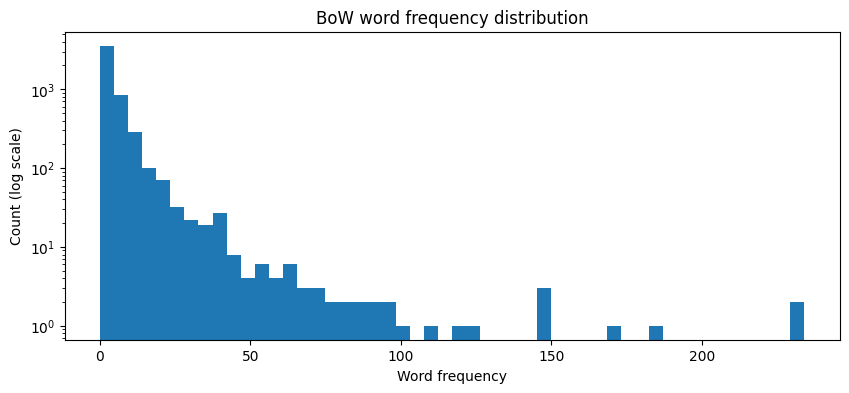

In [70]:
import matplotlib.pyplot as plt
word_counts = bow_stop.toarray()[:500].sum(axis=0)
plt.figure(figsize=(10, 4))
plt.hist(word_counts, bins=50, log=True)
plt.xlabel("Word frequency")
plt.ylabel("Count (log scale)")
plt.title("BoW word frequency distribution")
plt.show()

In [71]:
bow_df = pd.DataFrame(
    bow_stop[:5].toarray(),
    columns=vectorizer_stop.get_feature_names_out()
)
bow_df.head()

,000,10,100,10th,11,11th,12,12th,13,13th,...,zenon,zeon,zero,zhang,zodiac,zombie,zombies,zone,zoo,zorori
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,4,0,0,0,0,0,0,0,0,0


In [72]:
class BoWRecommender(AlgoBase):
    def __init__(self):
        AlgoBase.__init__(self)

    def fit(self, trainset):
        AlgoBase.fit(self, trainset)

        raw_ids   = [trainset.to_raw_iid(i) for i in trainset.all_items()]
        known     = [r for r in raw_ids if r in _synopsis_df.index]
        anime_sub = _synopsis_df.loc[known]

        vectorizer       = CountVectorizer(stop_words="english", max_features=5000)
        bow_matrix       = vectorizer.fit_transform(anime_sub["sypnopsis"])
        self.feat_matrix = normalize(bow_matrix, norm="l2")
        self.item_idx    = {raw_id: idx for idx, raw_id in enumerate(anime_sub.index)}

        self.user_items = {
            u: [(self.item_idx[trainset.to_raw_iid(j)], r)
                for j, r in trainset.ur[u]
                if trainset.to_raw_iid(j) in self.item_idx]
            for u in trainset.all_users()
        }
        return self

    def test(self, testset, verbose=False):
        from collections import defaultdict
        from surprise import Prediction

        user_tests = defaultdict(list)
        for uid, iid, r_ui in testset:
            user_tests[uid].append((iid, r_ui))

        predictions = []
        global_mean = self.trainset.global_mean
        lo, hi = self.trainset.rating_scale

        for raw_uid, test_items in user_tests.items():
            try:
                iuid       = self.trainset.to_inner_uid(raw_uid)
                user_rated = self.user_items.get(iuid, [])
            except ValueError:
                user_rated = []

            known   = [(iid, r) for iid, r in test_items if iid in self.item_idx and user_rated]
            unknown = [(iid, r) for iid, r in test_items if iid not in self.item_idx or not user_rated]

            if known:
                test_idxs  = [self.item_idx[iid] for iid, _ in known]
                rated_idxs = [idx for idx, _ in user_rated]
                ratings    = np.array([r for _, r in user_rated])

                result = self.feat_matrix[test_idxs].dot(self.feat_matrix[rated_idxs].T)
                sims   = result.toarray() if hasattr(result, "toarray") else np.asarray(result)

                for j, (raw_iid, r_ui) in enumerate(known):
                    s   = sims[j]
                    pos = s > 0
                    est = float(s[pos] @ ratings[pos] / s[pos].sum()) if pos.any() else global_mean
                    predictions.append(Prediction(raw_uid, raw_iid, r_ui, min(hi, max(lo, est)), {}))

            for raw_iid, r_ui in unknown:
                predictions.append(Prediction(raw_uid, raw_iid, r_ui, global_mean, {}))

        return predictions

    def estimate(self, u, i):
        if str(i).startswith("UKN__"):
            return self.trainset.global_mean
        raw_i = self.trainset.to_raw_iid(i)
        if raw_i not in self.item_idx or not self.user_items.get(u):
            return self.trainset.global_mean
        vec_i      = np.asarray(self.feat_matrix[self.item_idx[raw_i]].todense()).flatten()
        rated_idxs = [idx for idx, _ in self.user_items[u]]
        ratings    = np.array([r for _, r in self.user_items[u]])
        sims       = np.asarray(self.feat_matrix[rated_idxs].dot(vec_i)).flatten()
        pos        = sims > 0
        if not pos.any():
            return self.trainset.global_mean
        return float(sims[pos] @ ratings[pos] / sims[pos].sum())

In [73]:
bow = BoWRecommender()

bow.fit(trainset)
acc = eval_accuracy(bow.test(testset))

bow.fit(trainset_cov)
cov_preds = bow.test(antitestset_cov)
cov = eval_coverage(cov_preds, catalog, anime_meta)
del cov_preds; gc.collect()

results["BoW"] = {**acc, **cov}
pd.Series(results["BoW"])

RMSE                      1.4631
MAE                       1.1058
Precision@10              0.7664
Recall@10                 0.5019
NDCG@10                   0.9591
Coverage                 12.6700
Personalization           0.9625
Intra-List Similarity     0.2239
dtype: float64

In [74]:
cv_results = cross_validate(
    BoWRecommender(), data,
    measures=["RMSE", "MAE"],
    cv=KFold(n_splits=5, random_state=SEED),
    return_train_measures=True,
    n_jobs=1,
    verbose=False
)
pd.DataFrame(cv_results)[["test_rmse", "test_mae", "train_rmse", "train_mae"]].agg(["mean", "std"])

,test_rmse,test_mae,train_rmse,train_mae
mean,1.464582,1.106079,1.29110,0.969896
std,0.002306,0.001406,0.00061,0.000429


## TF-IDF Recommender

In [75]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
tfidf_matrix = tfidf_vectorizer.fit_transform(_synopsis_df["sypnopsis"])
print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("BoW matrix shape:   ", bow_stop.shape)

TF-IDF matrix shape: (16214, 5000)
BoW matrix shape:    (16214, 5000)


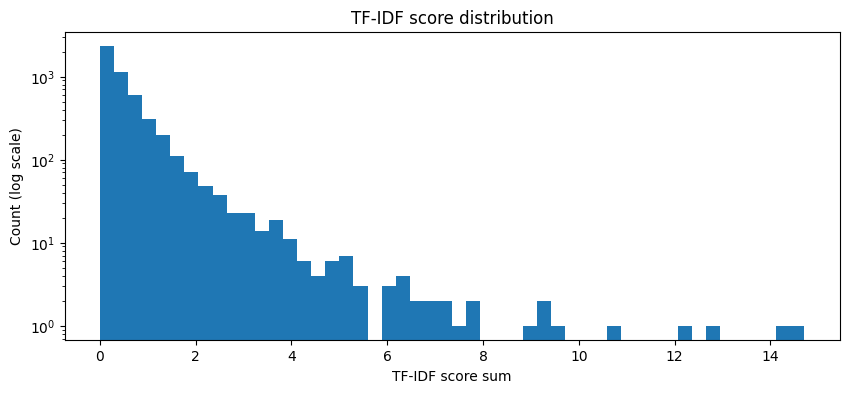

In [76]:
tfidf_scores = tfidf_matrix[:500].toarray().sum(axis=0)
plt.figure(figsize=(10, 4))
plt.hist(tfidf_scores, bins=50, log=True)
plt.xlabel("TF-IDF score sum")
plt.ylabel("Count (log scale)")
plt.title("TF-IDF score distribution")
plt.show()

In [77]:
tfidf_df = pd.DataFrame(
    tfidf_matrix[:5].toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)
tfidf_df.head()

,000,10,100,10th,11,11th,12,12th,13,13th,...,zenon,zeon,zero,zhang,zodiac,zombie,zombies,zone,zoo,zorori
0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.392828,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.536027,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Lemmatization

*[Your note on why lemmatization was not used]*

In [78]:
class TFIDFRecommender(AlgoBase):
    def __init__(self):
        AlgoBase.__init__(self)

    def fit(self, trainset):
        AlgoBase.fit(self, trainset)

        raw_ids   = [trainset.to_raw_iid(i) for i in trainset.all_items()]
        known     = [r for r in raw_ids if r in _synopsis_df.index]
        anime_sub = _synopsis_df.loc[known]

        vect             = TfidfVectorizer(stop_words="english", max_features=5000)
        tfidf_mat        = vect.fit_transform(anime_sub["sypnopsis"])
        self.feat_matrix = normalize(tfidf_mat, norm="l2")
        self.item_idx    = {raw_id: idx for idx, raw_id in enumerate(anime_sub.index)}

        self.user_items = {
            u: [(self.item_idx[trainset.to_raw_iid(j)], r)
                for j, r in trainset.ur[u]
                if trainset.to_raw_iid(j) in self.item_idx]
            for u in trainset.all_users()
        }
        return self

    def test(self, testset, verbose=False):
        from collections import defaultdict
        from surprise import Prediction

        user_tests = defaultdict(list)
        for uid, iid, r_ui in testset:
            user_tests[uid].append((iid, r_ui))

        predictions = []
        global_mean = self.trainset.global_mean
        lo, hi = self.trainset.rating_scale

        for raw_uid, test_items in user_tests.items():
            try:
                iuid       = self.trainset.to_inner_uid(raw_uid)
                user_rated = self.user_items.get(iuid, [])
            except ValueError:
                user_rated = []

            known   = [(iid, r) for iid, r in test_items if iid in self.item_idx and user_rated]
            unknown = [(iid, r) for iid, r in test_items if iid not in self.item_idx or not user_rated]

            if known:
                test_idxs  = [self.item_idx[iid] for iid, _ in known]
                rated_idxs = [idx for idx, _ in user_rated]
                ratings    = np.array([r for _, r in user_rated])

                result = self.feat_matrix[test_idxs].dot(self.feat_matrix[rated_idxs].T)
                sims   = result.toarray() if hasattr(result, "toarray") else np.asarray(result)

                for j, (raw_iid, r_ui) in enumerate(known):
                    s   = sims[j]
                    pos = s > 0
                    est = float(s[pos] @ ratings[pos] / s[pos].sum()) if pos.any() else global_mean
                    predictions.append(Prediction(raw_uid, raw_iid, r_ui, min(hi, max(lo, est)), {}))

            for raw_iid, r_ui in unknown:
                predictions.append(Prediction(raw_uid, raw_iid, r_ui, global_mean, {}))

        return predictions

    def estimate(self, u, i):
        if str(i).startswith("UKN__"):
            return self.trainset.global_mean
        raw_i = self.trainset.to_raw_iid(i)
        if raw_i not in self.item_idx or not self.user_items.get(u):
            return self.trainset.global_mean
        vec_i      = np.asarray(self.feat_matrix[self.item_idx[raw_i]].todense()).flatten()
        rated_idxs = [idx for idx, _ in self.user_items[u]]
        ratings    = np.array([r for _, r in self.user_items[u]])
        sims       = np.asarray(self.feat_matrix[rated_idxs].dot(vec_i)).flatten()
        pos        = sims > 0
        if not pos.any():
            return self.trainset.global_mean
        return float(sims[pos] @ ratings[pos] / sims[pos].sum())

In [79]:
tfidf = TFIDFRecommender()

tfidf.fit(trainset)
acc = eval_accuracy(tfidf.test(testset))

tfidf.fit(trainset_cov)
cov_preds = tfidf.test(antitestset_cov)
cov = eval_coverage(cov_preds, catalog, anime_meta)
del cov_preds; gc.collect()

results["TF-IDF"] = {**acc, **cov}
pd.Series(results["TF-IDF"])

RMSE                      1.4517
MAE                       1.0943
Precision@10              0.7746
Recall@10                 0.5043
NDCG@10                   0.9633
Coverage                 13.2900
Personalization           0.9655
Intra-List Similarity     0.2205
dtype: float64

In [80]:
cv_results = cross_validate(
    TFIDFRecommender(), data,
    measures=["RMSE", "MAE"],
    cv=KFold(n_splits=5, random_state=SEED),
    return_train_measures=True,
    n_jobs=1,
    verbose=False
)
pd.DataFrame(cv_results)[["test_rmse", "test_mae", "train_rmse", "train_mae"]].agg(["mean", "std"])

,test_rmse,test_mae,train_rmse,train_mae
mean,1.453174,1.094687,1.198056,0.893540
std,0.002152,0.001326,0.000671,0.000464


## BERT Recommender

In [82]:
from sentence_transformers import SentenceTransformer

_bert_model = SentenceTransformer("all-MiniLM-L6-v2")
_bert_cache = {}

synopses_all = _synopsis_df["sypnopsis"].tolist()
ids_all      = _synopsis_df.index.tolist()
embeddings_all = _bert_model.encode(synopses_all, show_progress_bar=True, batch_size=64)
for mid, emb in zip(ids_all, embeddings_all):
    _bert_cache[mid] = emb

print("BoW matrix shape:        ", bow_stop.shape)
print("TF-IDF matrix shape:     ", tfidf_matrix.shape)
print("BERT embeddings shape:   ", embeddings_all.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/254 [00:00<?, ?it/s]

BoW matrix shape:         (16214, 5000)
TF-IDF matrix shape:      (16214, 5000)
BERT embeddings shape:    (16214, 384)


In [83]:
embeddings_df = pd.DataFrame(embeddings_all, index=_synopsis_df.index)
embeddings_df.head()

,0,1,2,3,4,5,6,7,8,9,...,374,375,376,377,378,379,380,381,382,383
MAL_ID,,,,,,,,,,,,,,,,,,,,,
1,-0.079320,-0.031990,-0.054948,-0.027695,0.019967,0.048179,0.058222,0.011789,-0.004828,-0.019782,...,0.034524,-0.006011,-0.038581,0.065660,0.007235,-0.020745,0.029754,-0.067886,0.012642,-0.042742
5,-0.074500,0.069052,0.016639,0.036340,0.081231,0.009334,0.036593,0.076075,-0.034812,0.020394,...,0.062196,-0.055485,-0.024611,0.042608,-0.021842,0.026708,0.037085,-0.180263,-0.014235,0.019607
6,0.018597,0.089144,-0.042042,0.016114,0.058198,0.040770,0.143477,0.034466,-0.003781,0.033659,...,0.030565,0.009016,-0.077341,-0.015655,-0.012503,-0.015565,0.007478,-0.124750,0.020182,-0.040823
7,-0.030945,-0.006160,-0.057169,0.052504,0.012212,0.013273,0.159179,0.052044,0.042337,0.012396,...,-0.046539,0.042434,0.029670,-0.044752,0.002298,-0.040043,0.013019,-0.056087,0.072019,-0.038276
8,-0.035770,0.067944,-0.100477,-0.044423,0.034286,0.076920,0.033770,0.010735,-0.011177,-0.001312,...,-0.058995,-0.000684,-0.064772,0.021189,-0.038982,0.013368,0.041429,-0.068741,0.075173,-0.000356


In [84]:
class BERTRecommender(AlgoBase):
    def __init__(self):
        AlgoBase.__init__(self)

    def fit(self, trainset):
        AlgoBase.fit(self, trainset)

        raw_ids = [trainset.to_raw_iid(i) for i in trainset.all_items()]
        known   = [r for r in raw_ids if r in _bert_cache]

        feat_matrix = np.array([_bert_cache[r] for r in known])
        norms = np.linalg.norm(feat_matrix, axis=1, keepdims=True)
        norms[norms == 0] = 1
        self.feat_matrix = feat_matrix / norms
        self.item_idx    = {raw_id: idx for idx, raw_id in enumerate(known)}

        self.user_items = {
            u: [(self.item_idx[trainset.to_raw_iid(j)], r)
                for j, r in trainset.ur[u]
                if trainset.to_raw_iid(j) in self.item_idx]
            for u in trainset.all_users()
        }
        return self

    def test(self, testset, verbose=False):
        from collections import defaultdict
        from surprise import Prediction

        user_tests = defaultdict(list)
        for uid, iid, r_ui in testset:
            user_tests[uid].append((iid, r_ui))

        predictions = []
        global_mean = self.trainset.global_mean
        lo, hi = self.trainset.rating_scale

        for raw_uid, test_items in user_tests.items():
            try:
                iuid       = self.trainset.to_inner_uid(raw_uid)
                user_rated = self.user_items.get(iuid, [])
            except ValueError:
                user_rated = []

            known   = [(iid, r) for iid, r in test_items if iid in self.item_idx and user_rated]
            unknown = [(iid, r) for iid, r in test_items if iid not in self.item_idx or not user_rated]

            if known:
                test_idxs  = [self.item_idx[iid] for iid, _ in known]
                rated_idxs = [idx for idx, _ in user_rated]
                ratings    = np.array([r for _, r in user_rated])

                sims = self.feat_matrix[test_idxs] @ self.feat_matrix[rated_idxs].T

                for j, (raw_iid, r_ui) in enumerate(known):
                    s   = sims[j]
                    pos = s > 0
                    est = float(s[pos] @ ratings[pos] / s[pos].sum()) if pos.any() else global_mean
                    predictions.append(Prediction(raw_uid, raw_iid, r_ui, min(hi, max(lo, est)), {}))

            for raw_iid, r_ui in unknown:
                predictions.append(Prediction(raw_uid, raw_iid, r_ui, global_mean, {}))

        return predictions

    def estimate(self, u, i):
        if str(i).startswith("UKN__"):
            return self.trainset.global_mean
        raw_i = self.trainset.to_raw_iid(i)
        if raw_i not in self.item_idx or not self.user_items.get(u):
            return self.trainset.global_mean
        vec_i      = self.feat_matrix[self.item_idx[raw_i]]
        rated_idxs = [idx for idx, _ in self.user_items[u]]
        ratings    = np.array([r for _, r in self.user_items[u]])
        sims       = self.feat_matrix[rated_idxs] @ vec_i
        pos        = sims > 0
        if not pos.any():
            return self.trainset.global_mean
        return float(sims[pos] @ ratings[pos] / sims[pos].sum())

In [85]:
bert = BERTRecommender()

bert.fit(trainset)
acc = eval_accuracy(bert.test(testset))

bert.fit(trainset_cov)
cov_preds = bert.test(antitestset_cov)
cov = eval_coverage(cov_preds, catalog, anime_meta)
del cov_preds; gc.collect()

results["BERT"] = {**acc, **cov}
pd.Series(results["BERT"])

RMSE                      1.4848
MAE                       1.1255
Precision@10              0.7616
Recall@10                 0.5011
NDCG@10                   0.9581
Coverage                 11.5400
Personalization           0.9573
Intra-List Similarity     0.2519
dtype: float64

In [86]:
cv_results = cross_validate(
    BERTRecommender(), data,
    measures=["RMSE", "MAE"],
    cv=KFold(n_splits=5, random_state=SEED),
    return_train_measures=True,
    n_jobs=1,
    verbose=False
)
pd.DataFrame(cv_results)[["test_rmse", "test_mae", "train_rmse", "train_mae"]].agg(["mean", "std"])

,test_rmse,test_mae,train_rmse,train_mae
mean,1.487058,1.126429,1.448358,1.098418
std,0.002727,0.001546,0.000618,0.000453


## NER Recommender (Experimental)

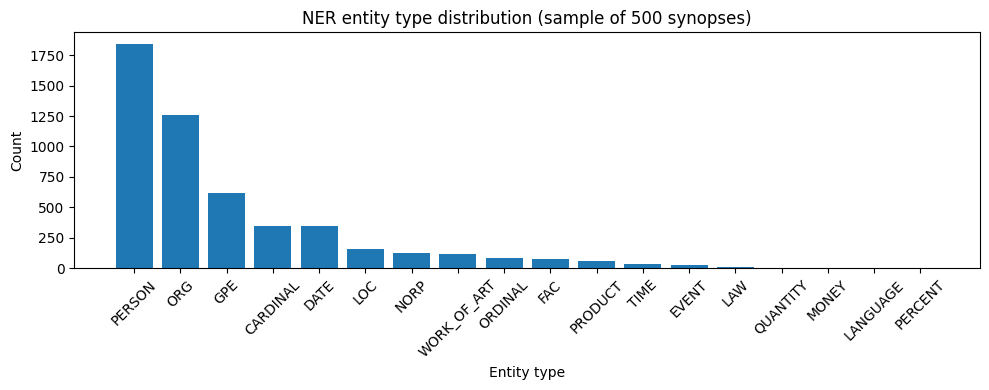

Avg entities per synopsis: 10.21
Max entities per synopsis: 26
Synopses with 0 entities:  0


In [88]:
import spacy
nlp_ner = spacy.load("en_core_web_sm")

def extract_entities(text):
    doc = nlp_ner(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

sample_entities = _synopsis_df["sypnopsis"].head(500).apply(extract_entities)

import matplotlib.pyplot as plt
from collections import Counter

all_labels = [label for ents in sample_entities for _, label in ents]
label_counts = Counter(all_labels)
labels, counts = zip(*sorted(label_counts.items(), key=lambda x: -x[1]))
plt.figure(figsize=(10, 4))
plt.bar(labels, counts)
plt.xlabel("Entity type")
plt.ylabel("Count")
plt.title("NER entity type distribution (sample of 500 synopses)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

entity_counts_per_doc = sample_entities.apply(len)
print("Avg entities per synopsis:", round(entity_counts_per_doc.mean(), 2))
print("Max entities per synopsis:", entity_counts_per_doc.max())
print("Synopses with 0 entities: ", (entity_counts_per_doc == 0).sum())

In [89]:
entity_strings = _synopsis_df["sypnopsis"].head(500).apply(
    lambda t: " ".join([e.text for e in nlp_ner(t).ents])
)
pd.DataFrame({"synopsis": _synopsis_df["sypnopsis"].head(5),
              "entities": entity_strings.head(5)})

,synopsis,entities
MAL_ID,,
1,"In the year 2071, humanity has colonized sever...",the year 2071 Earth The Inter Solar System Pol...
5,"other day, another bounty—such is the life of ...",Bebop Faye Mars three hundred million Bebop Ed...
6,"Vash the Stampede is the man with a $$60,000,0...","Stampede $$60,000,000,000 The Humanoid Typhoon..."
7,ches are individuals with special powers like ...,Robin 15-year-old Italy Japan STN Japan Divisi...
8,It is the dark century and the people are suff...,the dark century Vandel The Vandel Busters the...


In [90]:
def get_entity_string(text):
    doc = nlp_ner(text)
    return " ".join([ent.text for ent in doc.ents])

_ner_strings = _synopsis_df["sypnopsis"].apply(get_entity_string)

from sklearn.feature_extraction.text import CountVectorizer as CV
ner_vect = CV(max_features=5000)
ner_mat  = ner_vect.fit_transform(_ner_strings)
print("NER matrix shape:", ner_mat.shape)
print("BoW matrix shape:", bow_stop.shape)

NER matrix shape: (16214, 5000)
BoW matrix shape: (16214, 5000)


*placeholder for comment about how NER can have a lot of unique names, locations etc.*

In [91]:
class NERRecommender(AlgoBase):
    def __init__(self):
        AlgoBase.__init__(self)

    def fit(self, trainset):
        AlgoBase.fit(self, trainset)

        raw_ids   = [trainset.to_raw_iid(i) for i in trainset.all_items()]
        known     = [r for r in raw_ids if r in _synopsis_df.index]
        anime_sub = _synopsis_df.loc[known]

        ner_texts        = anime_sub["sypnopsis"].apply(get_entity_string)
        vect             = CountVectorizer(max_features=5000)
        ner_matrix       = vect.fit_transform(ner_texts)
        self.feat_matrix = normalize(ner_matrix, norm="l2")
        self.item_idx    = {raw_id: idx for idx, raw_id in enumerate(anime_sub.index)}

        self.user_items = {
            u: [(self.item_idx[trainset.to_raw_iid(j)], r)
                for j, r in trainset.ur[u]
                if trainset.to_raw_iid(j) in self.item_idx]
            for u in trainset.all_users()
        }
        return self

    def test(self, testset, verbose=False):
        from collections import defaultdict
        from surprise import Prediction

        user_tests = defaultdict(list)
        for uid, iid, r_ui in testset:
            user_tests[uid].append((iid, r_ui))

        predictions = []
        global_mean = self.trainset.global_mean
        lo, hi = self.trainset.rating_scale

        for raw_uid, test_items in user_tests.items():
            try:
                iuid       = self.trainset.to_inner_uid(raw_uid)
                user_rated = self.user_items.get(iuid, [])
            except ValueError:
                user_rated = []

            known   = [(iid, r) for iid, r in test_items if iid in self.item_idx and user_rated]
            unknown = [(iid, r) for iid, r in test_items if iid not in self.item_idx or not user_rated]

            if known:
                test_idxs  = [self.item_idx[iid] for iid, _ in known]
                rated_idxs = [idx for idx, _ in user_rated]
                ratings    = np.array([r for _, r in user_rated])

                result = self.feat_matrix[test_idxs].dot(self.feat_matrix[rated_idxs].T)
                sims   = result.toarray() if hasattr(result, "toarray") else np.asarray(result)

                for j, (raw_iid, r_ui) in enumerate(known):
                    s   = sims[j]
                    pos = s > 0
                    est = float(s[pos] @ ratings[pos] / s[pos].sum()) if pos.any() else global_mean
                    predictions.append(Prediction(raw_uid, raw_iid, r_ui, min(hi, max(lo, est)), {}))

            for raw_iid, r_ui in unknown:
                predictions.append(Prediction(raw_uid, raw_iid, r_ui, global_mean, {}))

        return predictions

    def estimate(self, u, i):
        if str(i).startswith("UKN__"):
            return self.trainset.global_mean
        raw_i = self.trainset.to_raw_iid(i)
        if raw_i not in self.item_idx or not self.user_items.get(u):
            return self.trainset.global_mean
        vec_i      = np.asarray(self.feat_matrix[self.item_idx[raw_i]].todense()).flatten()
        rated_idxs = [idx for idx, _ in self.user_items[u]]
        ratings    = np.array([r for _, r in self.user_items[u]])
        sims       = np.asarray(self.feat_matrix[rated_idxs].dot(vec_i)).flatten()
        pos        = sims > 0
        if not pos.any():
            return self.trainset.global_mean
        return float(sims[pos] @ ratings[pos] / sims[pos].sum())

In [92]:
ner = NERRecommender()

ner.fit(trainset)
acc = eval_accuracy(ner.test(testset))

ner.fit(trainset_cov)
cov_preds = ner.test(antitestset_cov)
cov = eval_coverage(cov_preds, catalog, anime_meta)
del cov_preds; gc.collect()

results["NER"] = {**acc, **cov}
pd.Series(results["NER"])

RMSE                      1.4951
MAE                       1.1192
Precision@10              0.7512
Recall@10                 0.4975
NDCG@10                   0.9564
Coverage                 17.9700
Personalization           0.9825
Intra-List Similarity     0.2329
dtype: float64

In [93]:
cv_results = cross_validate(
    NERRecommender(), data,
    measures=["RMSE", "MAE"],
    cv=KFold(n_splits=5, random_state=SEED),
    return_train_measures=True,
    n_jobs=1,
    verbose=False
)
pd.DataFrame(cv_results)[["test_rmse", "test_mae", "train_rmse", "train_mae"]].agg(["mean", "std"])

KeyboardInterrupt: 

*[I need to write here about the limitations of NER]*

# Model Comparison

In [94]:
results_df = pd.DataFrame(results).T
results_df

,RMSE,MAE,Precision@10,Recall@10,NDCG@10,Coverage,Personalization,Intra-List Similarity
Popular,1.6907,1.2893,0.8003,0.5136,0.9728,0.65,0.1593,0.3046
Random,2.4038,1.9041,0.7183,0.4844,0.9472,38.98,0.9984,0.1925
SVD,1.2348,0.9217,0.8176,0.5246,0.9752,1.45,0.5811,0.2701
Metadata,1.4589,1.1047,0.7786,0.5076,0.9618,12.18,0.9072,0.2826
BoW,1.4631,1.1058,0.7664,0.5019,0.9591,12.67,0.9625,0.2239
TF-IDF,1.4517,1.0943,0.7746,0.5043,0.9633,13.29,0.9655,0.2205
BERT,1.4848,1.1255,0.7616,0.5011,0.9581,11.54,0.9573,0.2519
NER,1.4951,1.1192,0.7512,0.4975,0.9564,17.97,0.9825,0.2329


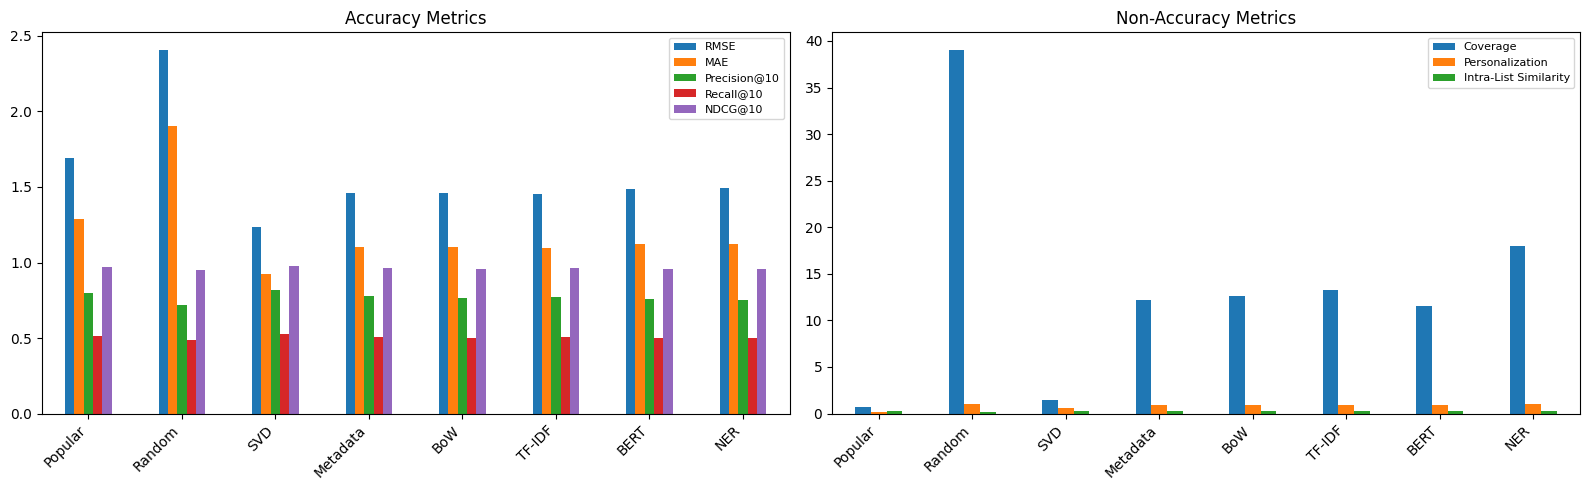

In [95]:
import matplotlib.pyplot as plt

accuracy_metrics  = ["RMSE", "MAE", "Precision@10", "Recall@10", "NDCG@10"]
coverage_metrics  = ["Coverage", "Personalization", "Intra-List Similarity"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

results_df[accuracy_metrics].plot(kind="bar", ax=axes[0])
axes[0].set_title("Accuracy Metrics")
axes[0].set_xticklabels(results_df.index, rotation=45, ha="right")
axes[0].legend(loc="upper right", fontsize=8)

results_df[coverage_metrics].plot(kind="bar", ax=axes[1])
axes[1].set_title("Non-Accuracy Metrics")
axes[1].set_xticklabels(results_df.index, rotation=45, ha="right")
axes[1].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

## Interpretation of results

From the model performance analysis above, we evaluated multiple recommendation approaches, including:
- popular, which is non personalized
- random, which is the baseline exploration
- collaborative filtering, which is SVD from 'surprise'
- content-based models such as metadata, bag of words, TF-IDF, BERT, and NER

The collaborative filtering achieved the best performance across all `accuracy_metrics`, which has the lowest RMSE and MAE, as well as the highest precision at 10, recall at 10, and NDCG at 10. This indicates that SVD is the most effective model for predicting user preferences based on historical interactions; however, it presents some limitations, such as low coverage and moderate personalization. This means that SVD is accurate but tends to recommend similar or popular items repeatedly.

For popularity mode, on the other hand, it also performs strongly in ranking metrics. It achieved high precision and NDCG, however very low personalization, meaning that it provides safe recommendations but lacks personalization.

And finally, as expected, the random model performed poorly in `accuracy_metrics` but it had extremely high coverage and high personalization, meaning that it is useful for exploration but not for exploitation.

And content-based models approaches such as metadata, bag of words, TF-IDF, BERT, and NER showed consistent performance across all metrics and provided a good balance between accuracy and diversity. Notably, TF-IDF and bag of words performed competitively with more complex models like BERT, surprisingly, and NER increases coverage and diversity. This all means that these models are strong for diversity, explainability, and personalization.

The results highlight fundamental trade-offs between accuracy and diversity. Collaborative filtering maximizes accuracy, while content-based and random approaches improve diversity, coverage, and personalization.

Given the observed trade-offs, a hybrid recommender system is required to combine the strengths of multiple approaches while mitigating their individual weaknesses.



# Hybrid RS

We will design a hybrid recommender system that uses SVD as the primary signal for accuracy, incorporates content-based models to improve diversity and semantic relevance, and includes small exploration components to increase coverage and avoid over-specialization.

The hybrid score is computed as:
`score(i) = w1 * SVD(i) + w2 * Context(i) + w3 * Popular(i)`

This is where SVD captures user-item interactions, content captures semantic similarity, and Poplar provides stability and fallback.



In [96]:
def minmax_dict(score_dict):
    vals = np.array(list(score_dict.values()), dtype=float)
    if len(vals) == 0:
        return {}
    lo, hi = vals.min(), vals.max()
    if hi == lo:
        return {k: 1.0 for k in score_dict}
    return {k: (v - lo) / (hi - lo) for k, v in score_dict.items()}

In [97]:
def build_hybrid_scores(uid, unseen_items, algo_svd, algo_tfidf, algo_meta, popular_model,
                        w_svd=0.50, w_tfidf=0.25, w_meta=0.15, w_pop=0.10):
    svd_scores = {iid: algo_svd.predict(uid, iid).est for iid in unseen_items}
    tfidf_scores = {iid: algo_tfidf.predict(uid, iid).est for iid in unseen_items}
    meta_scores = {iid: algo_meta.predict(uid, iid).est for iid in unseen_items}
    pop_scores = {iid: popular_model.predict(uid, iid).est for iid in unseen_items}

    svd_n = minmax_dict(svd_scores)
    tfidf_n = minmax_dict(tfidf_scores)
    meta_n = minmax_dict(meta_scores)
    pop_n = minmax_dict(pop_scores)

    hybrid_scores = {}
    for iid in unseen_items:
        hybrid_scores[iid] = (
            w_svd   * svd_n.get(iid, 0.0) +
            w_tfidf * tfidf_n.get(iid, 0.0) +
            w_meta  * meta_n.get(iid, 0.0) +
            w_pop   * pop_n.get(iid, 0.0)
        )
    return hybrid_scores

Reccomendation for sample user

In [98]:
uid = 75051

already_rated = set(ratings_cf[ratings_cf["user_id"] == uid]["anime_id"])
all_anime_ids = set(ratings_cf["anime_id"].unique())
items_to_predict = list(all_anime_ids - already_rated)

hybrid_scores = build_hybrid_scores(
    uid=uid,
    unseen_items=items_to_predict,
    algo_svd=algo,          # your trained SVD model
    algo_tfidf=tfidf,       # your trained TFIDFRecommender
    algo_meta=meta,         # your trained MetadataRecommender
    popular_model=popular,  # your trained PopularRecommender
    w_svd=0.50,
    w_tfidf=0.25,
    w_meta=0.15,
    w_pop=0.10
)

top_10_hybrid = pd.DataFrame(
    sorted(hybrid_scores.items(), key=lambda x: x[1], reverse=True)[:10],
    columns=["anime_id", "hybrid_score"]
)

top_10_hybrid = top_10_hybrid.merge(
    anime[["MAL_ID", "Name", "Genres", "Type", "Score", "Members"]],
    left_on="anime_id",
    right_on="MAL_ID",
    how="left"
)

top_10_hybrid[["Name", "hybrid_score", "Genres", "Type", "Score", "Members"]]

,Name,hybrid_score,Genres,Type,Score,Members
0,Gintama': Enchousen,1.000000,"Action, Comedy, Historical, Parody, Samurai, S...",TV,9.04,222819
1,Gintama°,0.999493,"Action, Comedy, Historical, Parody, Samurai, S...",TV,9.10,404121
2,Shingeki no Kyojin: The Final Season,0.998465,"Action, Drama, Fantasy, Military, Mystery, Sho...",TV,9.17,733260
3,3-gatsu no Lion 2nd Season,0.996947,"Drama, Game, Seinen, Slice of Life",TV,9.00,266243
4,Gintama Movie 2: Kanketsu-hen - Yorozuya yo Ei...,0.993820,"Action, Comedy, Historical, Parody, Samurai, S...",Movie,8.96,171119
5,Gintama',0.993180,"Action, Comedy, Historical, Parody, Samurai, S...",TV,9.08,365579
6,Steins;Gate,0.990921,"Sci-Fi, Thriller",TV,9.11,1771162
7,Fullmetal Alchemist: Brotherhood,0.990881,"Action, Adventure, Comedy, Drama, Fantasy, Mag...",TV,9.19,2248456
8,Shingeki no Kyojin Season 3 Part 2,0.990621,"Action, Drama, Fantasy, Military, Mystery, Sho...",TV,9.10,1073626
9,Hunter x Hunter (2011),0.990233,"Action, Adventure, Fantasy, Shounen, Super Power",TV,9.10,1673924


## Evaluation

Helper

In [103]:
from surprise import Prediction

def hybrid_testset_predictions(testset, algo_svd, algo_tfidf, algo_meta, popular_model,
                               w_svd=0.50, w_tfidf=0.25, w_meta=0.15, w_pop=0.10):
    by_user = defaultdict(list)
    for uid, iid, r_ui in testset:
        by_user[uid].append((iid, r_ui))

    predictions = []

    for uid, pairs in by_user.items():
        item_ids = [iid for iid, _ in pairs]

        svd_scores = {iid: algo_svd.predict(uid, iid).est for iid in item_ids}
        tfidf_scores = {iid: algo_tfidf.predict(uid, iid).est for iid in item_ids}
        meta_scores = {iid: algo_meta.predict(uid, iid).est for iid in item_ids}
        pop_scores = {iid: popular_model.predict(uid, iid).est for iid in item_ids}

        svd_n = minmax_dict(svd_scores)
        tfidf_n = minmax_dict(tfidf_scores)
        meta_n = minmax_dict(meta_scores)
        pop_n = minmax_dict(pop_scores)

        for iid, r_ui in pairs:
            est = (
                w_svd   * svd_n.get(iid, 0.0) +
                w_tfidf * tfidf_n.get(iid, 0.0) +
                w_meta  * meta_n.get(iid, 0.0) +
                w_pop   * pop_n.get(iid, 0.0)
            )

            est = est * 9 + 1

            predictions.append(Prediction(uid, iid, r_ui, est, {}))

    return predictions

In [104]:
hybrid_preds = hybrid_testset_predictions(
    testset=testset,
    algo_svd=algo,
    algo_tfidf=tfidf,
    algo_meta=meta,
    popular_model=popular,
    w_svd=0.50,
    w_tfidf=0.25,
    w_meta=0.15,
    w_pop=0.10
)

acc = eval_accuracy(hybrid_preds)
results["Hybrid"] = acc
pd.Series(results["Hybrid"])

RMSE            1.6476
MAE             1.2487
Precision@10    0.8366
Recall@10       0.5322
NDCG@10         0.9813
dtype: float64

In [105]:
hybrid_cov_preds = hybrid_testset_predictions(
    testset=antitestset_cov,
    algo_svd=algo_cov,
    algo_tfidf=tfidf,
    algo_meta=meta,
    popular_model=popular,
    w_svd=0.50,
    w_tfidf=0.25,
    w_meta=0.15,
    w_pop=0.10
)

cov = eval_coverage(hybrid_cov_preds, catalog, anime_meta)
results["Hybrid"] = {**acc, **cov}
pd.Series(results["Hybrid"])

RMSE                     1.6476
MAE                      1.2487
Precision@10             0.8366
Recall@10                0.5322
NDCG@10                  0.9813
Coverage                 2.9300
Personalization          0.7147
Intra-List Similarity    0.2731
dtype: float64

## Intepretation

In conclusion, the hybrid recommender improves ranking quality and personalization compared to @SVD(...)     while increasing coverage at the cost of slightly lowering the rating prediction accuracy. More specifically, this hybrid model achieves higher ranking performance than collaborative filtering, with improvements such as precision@10 or recall@10 and ndcg@10. This indicates that the hybrid is more effective at placing relevant items at the top of the recommendation list. In addition, the hybrid increases coverage and personalization compared to @SVD(...)  , suggesting that it becomes a broader and more specific user-specific set of items. However, there are some limitations, such as RMSE and MAE being worse than the collaborative filtering, indicating reduced accuracy in predicting exact rating values. This is expected, as the hybrid prioritizes ranking quality and diversity over precise rating prediction. Overall, the hybrid improved model provides a better balance between accuracy, diversity, and personalization, making it suitable for real-world recommendation scenarios. Some future implementations could be hyperparameter tuning, as this hybrid still has lots of potential to be discovered.